[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/WalterPaixaoCortes/big-data/blob/main/aula-big-data/demonstracao-lakehouse-medalhao.ipynb)

# Demonstração Prática: Plataformas de Big Data e um Lakehouse com Arquitetura Medalhão

Este notebook é uma demonstração prática dos conceitos apresentados no notebook de conceitos básicos desta mesma pasta: ecossistema de ferramentas de Big Data, arquitetura Lakehouse, camadas Medalhão (Bronze, Silver, Gold) e modelagem dimensional (fato, dimensão, SCD).

Vamos em quatro etapas: primeiro, um comparativo objetivo das principais plataformas de Big Data/Lakehouse disponíveis no mercado hoje. Depois, um mini Lakehouse rodando localmente, com pandas, só para fixar a mecânica de Bronze → Silver → Gold sem depender de nenhuma conta na nuvem. Em seguida, evoluímos essa mesma mecânica para um esquema estrela de verdade — fato e dimensões, incluindo uma dimensão com histórico completo (SCD Tipo 2). Por fim, um passo a passo de como o mesmo padrão é implementado de verdade em duas das plataformas mais usadas atualmente: **Microsoft Fabric** e **Databricks**.

## Comparativo de Ambientes de Big Data no Mercado

Não existe "a" ferramenta de Big Data — existe um mercado de plataformas que resolvem o mesmo problema (armazenamento e processamento distribuído, em arquitetura de Lakehouse) com peças e nomes diferentes. A tabela abaixo compara seis das plataformas mais relevantes hoje, nas mesmas dimensões que discutimos na teoria: formato de armazenamento, motor de processamento, orquestração, governança, cobrança, BI e streaming — das gigantes de nuvem a uma alternativa self-hosted.

| Plataforma | Formato de tabela aberto | Motor de processamento | Orquestração nativa | Catálogo / Governança | Modelo de cobrança | BI nativo | Streaming |
|---|---|---|---|---|---|---|---|
| **Databricks** | Delta Lake (padrão); também lê/grava Iceberg via UniForm | Apache Spark + Photon (motor SQL vetorizado) | Lakeflow Jobs (antigo "Databricks Workflows"; no menu aparece como "Jobs & Pipelines") | Unity Catalog (metastore + controle de acesso + linhagem automática) | DBU (Databricks Unit), consumo por segundo | AI/BI Dashboards + Genie (perguntas em linguagem natural) | Structured Streaming (nativo do Spark) |
| **Microsoft Fabric** | Delta Lake (padronizado em todos os motores) | Apache Spark (Notebooks) + motor SQL proprietário (item Warehouse) | Data Factory → item "Data pipeline" | OneLake catalog (+ integração opcional com Microsoft Purview) | CU (Capacity Unit), via capacidades F2 a F2048 | Power BI nativo (modo Direct Lake, sem cópia dos dados) | Eventstream (parte do Real-Time Intelligence) |
| **Snowflake** | Formato proprietário; suporte nativo a Apache Iceberg via Polaris/Horizon Catalog | Motor SQL proprietário; Snowpark para código em estilo Spark | Snowflake Tasks (`CREATE TASK ... AFTER`, formam um DAG) | Horizon Catalog, construído sobre o Polaris Catalog (open source) | Créditos, em 3 medidores: computação, armazenamento e serviços de nuvem | Snowsight (dashboards nativos) + conectores para Tableau/Power BI/Looker | Snowpipe Streaming |
| **AWS** | Apache Iceberg (padrão atual, incl. S3 Tables gerenciado) + Hive legado | Spark (EMR/Glue) + motores proprietários (Redshift, Athena) | AWS Glue Workflows; Step Functions/Amazon MWAA para orquestração mais ampla | AWS Glue Data Catalog + AWS Lake Formation (controle de acesso) | Por serviço: DPU-hora (Glue), hora de instância (EMR/Redshift), GB armazenado (S3) | Amazon QuickSight | Amazon Kinesis / Amazon MSK (Kafka gerenciado) |
| **Google Cloud** | Apache Iceberg, via "Lakehouse for Apache Iceberg" (renomeado do BigLake em 2026) | BigQuery (motor Dremel, serverless) + Spark (Dataproc) | Cloud Composer (Apache Airflow gerenciado) + Dataform | Dataplex Universal Catalog | Slots (BigQuery) ou DCU (Dataproc), por segundo | Looker + BigQuery BI Engine | Dataflow (Apache Beam) + Pub/Sub |
| **IOMETE** | Apache Iceberg (nativo; qualquer engine compatível — Trino, Flink, DuckDB, PyIceberg — lê as tabelas direto) | Apache Spark | Job Orchestrator próprio (construído sobre o Prefect) + plugin oficial para integrar com Apache Airflow | Data Catalog próprio, com controles de acesso por linha/coluna/tabela/usuário e organização em "Domains" | Licenciamento anual por vCPU (self-hosted); camada gratuita até 100 vCPUs | Nenhum nativo — conecta a Power BI/Tableau/Looker via endpoint SQL | Ingestão via Kafka/Kinesis/Pulsar, processado em Spark Streaming/Flink |

> 📝 **Nota:** os valores de cobrança variam por região, edição/contrato e volume negociado — por isso a tabela mostra apenas a *unidade* de consumo de cada plataforma (DBU, CU, Crédito...), não valores em R\$/US\$. Os links para a documentação oficial de cada item estão na seção "Saiba Mais", ao final.

Um pouco de contexto por trás de cada linha:

- **Databricks** foi fundada em 2013 pelos criadores do Apache Spark. Foi lá que os pesquisadores Matei Zaharia e Ali Ghodsi formalizaram o termo **"Lakehouse"** — o mesmo paper de 2021 que vimos no notebook de conceitos básicos desta pasta.
- **Microsoft Fabric** unifica em um único SaaS produtos que antes eram separados (Power BI, Synapse Analytics, Data Factory), com o **OneLake** funcionando como um "lake" lógico único para todo o tenant. "Lakehouse" é, literalmente, um tipo de item que se cria dentro de um workspace do Fabric.
- **Snowflake** foi pioneira em separar armazenamento e computação em unidades independentes e escaláveis (os "warehouses" virtuais), e abriu o código do **Polaris Catalog** para tornar tabelas Iceberg interoperáveis entre motores de diferentes fornecedores.
- **AWS**: o Amazon S3 (2006) é anterior ao próprio conceito de Lakehouse e se tornou a base de armazenamento sobre a qual boa parte do ecossistema de formatos abertos (Iceberg, Delta, Hudi) foi construído — inclusive em outras nuvens.
- **Google Cloud**: o paper do Dremel (2010) é a base da arquitetura serverless do BigQuery, um dos primeiros motores SQL MPP totalmente serverless do mercado.
- **IOMETE**: na contramão das outras cinco (todas SaaS gerenciado na nuvem do próprio fornecedor), é uma plataforma **self-hosted** — roda dentro da infraestrutura do cliente (on-premises, nuvem privada, pública ou híbrida), com o plano de controle da IOMETE nunca tendo acesso aos dados. Fundada em 2020 (Y Combinator, 2022), aposta em licenciamento por vCPU em vez de cobrança por consumo, e em Apache Iceberg puro em vez de um formato proprietário — o oposto do modelo das big techs de nuvem.

> 💡 **Dica:** repare que "orquestração nativa" e "processamento" quase sempre aparecem como produtos separados dentro da mesma plataforma (ex.: Glue Workflows ≠ EMR; Data Factory ≠ Spark no Fabric). Isso reflete a mesma separação entre as peças do ecossistema de Big Data que vimos na teoria — armazenamento, processamento e orquestração continuam sendo problemas distintos, mesmo quando uma única plataforma resolve todos eles.

## Colocando a Mão na Massa: um Mini Lakehouse Local

Antes de ir para a nuvem, vamos fixar a mecânica da arquitetura medalhão com uma versão mínima rodando localmente, com pandas, sobre os dados de `departamentos` que já conhecemos. A ideia não é reproduzir Delta Lake ou Spark — é isolar o padrão Bronze → Silver → Gold em três funções simples, para depois reconhecer exatamente as mesmas peças quando virmos a versão "de verdade" no Fabric e no Databricks.

Diagrama: as três funções que vamos escrever a seguir, cada uma cumprindo o papel de uma camada.

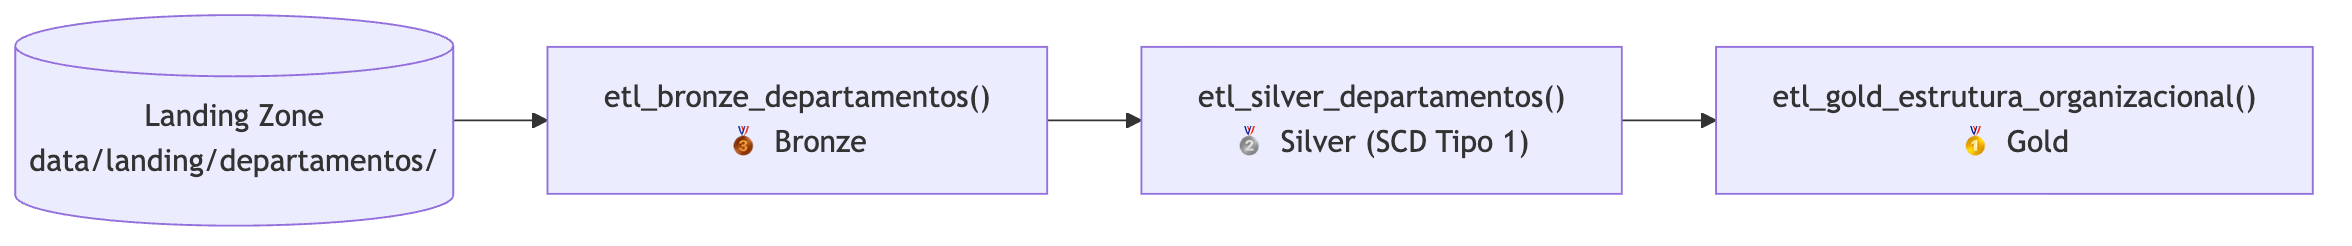

<details>
<summary>código-fonte do diagrama (mermaid)</summary>

```mermaid
flowchart LR
    L[("Landing Zone<br/>data/landing/departamentos/")] --> FB["etl_bronze_departamentos()<br/>🥉 Bronze"]
    FB --> FS["etl_silver_departamentos()<br/>🥈 Silver (SCD Tipo 1)"]
    FS --> FG["etl_gold_estrutura_organizacional()<br/>🥇 Gold"]
```

</details>

In [ ]:
import pandas as pd
import glob
import os
import time
from datetime import datetime

### Bronze: ingestão crua

A camada Bronze lê todas as partições mensais da landing zone exatamente como estão, sem limpar nem deduplicar nada — só adiciona metadados de auditoria (de qual arquivo veio, quando foi ingerido).

In [ ]:
def etl_bronze_departamentos(
    caminho_landing='../data/landing/departamentos',
    caminho_bronze='../data/lakehouse/bronze',
):
    # lê todas as partições mensais, sem transformar nada
    caminhos_particoes = sorted(glob.glob(f'{caminho_landing}/dt=*/departamentos.csv'))

    partes = []
    for caminho in caminhos_particoes:
        df_particao = pd.read_csv(caminho)
        # metadados de auditoria: de onde veio e quando foi ingerido
        df_particao['_arquivo_origem'] = caminho
        df_particao['_timestamp_ingestao'] = datetime.now().isoformat(timespec='seconds')
        partes.append(df_particao)

    df_bronze = pd.concat(partes, ignore_index=True)

    os.makedirs(caminho_bronze, exist_ok=True)
    df_bronze.to_csv(f'{caminho_bronze}/departamentos.csv', index=False)

    print(f'[BRONZE] {len(df_bronze)} linhas gravadas a partir de {len(caminhos_particoes)} partições.')
    return df_bronze

### Silver: limpeza e deduplicação

A camada Silver lê o Bronze, corrige tipos, limpa espaços em branco e reduz cada departamento à sua versão mais recente.

In [ ]:
def etl_silver_departamentos(
    caminho_bronze='../data/lakehouse/bronze',
    caminho_silver='../data/lakehouse/silver',
):
    df_bronze = pd.read_csv(f'{caminho_bronze}/departamentos.csv')

    # tipagem explícita e limpeza de espaços em branco
    df_bronze['data_extracao'] = pd.to_datetime(df_bronze['data_extracao'])
    df_bronze['nome_departamento'] = df_bronze['nome_departamento'].str.strip()

    # mantém apenas o registro mais recente de cada departamento
    df_silver = (
        df_bronze
        .sort_values('data_extracao')
        .drop_duplicates(subset='departamento_id', keep='last')
        .drop(columns=['_arquivo_origem', '_timestamp_ingestao'])
        .reset_index(drop=True)
    )

    os.makedirs(caminho_silver, exist_ok=True)
    df_silver.to_csv(f'{caminho_silver}/departamentos.csv', index=False)

    print(f'[SILVER] {len(df_silver)} departamentos únicos após deduplicação.')
    return df_silver

> ⚠️ **Atenção:** para manter a demonstração simples, aqui ficamos apenas com a versão mais recente de cada departamento — o equivalente a uma SCD Tipo 1. Um pipeline de produção normalmente usaria SCD Tipo 2 (como vimos na teoria) para preservar o histórico completo de mudanças, em vez de sobrescrevê-lo.

### Gold: modelo pronto para consumo analítico

A camada Gold lê o Silver e produz uma tabela já agregada para responder a uma pergunta de negócio específica — nesse caso, uma pergunta de **analytics descritiva** simples: quantos departamentos subordinados cada área tem?

In [ ]:
def etl_gold_estrutura_organizacional(
    caminho_silver='../data/lakehouse/silver',
    caminho_gold='../data/lakehouse/gold',
):
    df_silver = pd.read_csv(f'{caminho_silver}/departamentos.csv')

    # conta quantos departamentos têm cada departamento_id como pai
    df_gold = (
        df_silver
        .dropna(subset=['departamento_pai_id'])
        .groupby('departamento_pai_id')
        .size()
        .reset_index(name='qtd_subdepartamentos')
        .rename(columns={'departamento_pai_id': 'departamento_id'})
        .merge(df_silver[['departamento_id', 'nome_departamento']], on='departamento_id', how='left')
        .sort_values('qtd_subdepartamentos', ascending=False)
    )

    os.makedirs(caminho_gold, exist_ok=True)
    df_gold.to_csv(f'{caminho_gold}/estrutura_organizacional.csv', index=False)

    print(f'[GOLD] tabela "estrutura_organizacional" gerada com {len(df_gold)} linhas.')
    return df_gold

### Orquestração: encadeando as três etapas

Uma orquestração de verdade (como veremos a seguir no Fabric e no Databricks) cuida de agendamento, novas tentativas em caso de falha, alertas e execução em paralelo quando possível. Aqui, uma versão mínima: apenas respeitar a ordem de dependência (Bronze antes de Silver, Silver antes de Gold) e registrar o resultado de cada etapa.

In [ ]:
# ORQUESTRAÇÃO (simplificada): executa as etapas em sequência, respeitando a dependência Bronze -> Silver -> Gold
etapas = [
    ('bronze', etl_bronze_departamentos),
    ('silver', etl_silver_departamentos),
    ('gold', etl_gold_estrutura_organizacional),
]

print('Iniciando pipeline "departamentos"\n' + '-' * 40)
for nome_etapa, funcao_etapa in etapas:
    inicio = time.time()
    funcao_etapa()
    duracao = time.time() - inicio
    print(f'  -> etapa "{nome_etapa}" concluída em {duracao:.2f}s')
print('-' * 40 + '\nPipeline concluído com sucesso.')

In [ ]:
# conferindo o resultado final da camada Gold
pd.read_csv('../data/lakehouse/gold/estrutura_organizacional.csv')

Repare que a tabela Gold já responde diretamente a uma pergunta de negócio ("Diretoria tem 6 departamentos subordinados, Vendas tem 1"), sem exigir nenhum `join` ou tratamento adicional de quem for consumi-la — exatamente o papel que a camada Gold deve cumprir.

## Modelagem Dimensional na Prática: Construindo um Esquema Estrela

A tabela `estrutura_organizacional` que acabamos de gerar já é útil, mas é uma Gold "achatada": uma única tabela, sem separação explícita entre fato e dimensão. Vamos usar o restante do conjunto de dados desta pasta — `cargos` e `funcionarios`, que já conhecemos da aula de conceitos básicos, mais `eventos` (o histórico de admissões, promoções, transferências, avaliações e desligamentos) — para construir um esquema estrela de verdade: uma tabela fato cercada de dimensões, colocando em prática tudo que vimos na seção de modelagem de dados.

### Declarando o Grão

Antes de escrever qualquer código, vale aplicar a recomendação de Kimball e declarar o grão da nossa futura tabela fato: **uma linha representa um evento de RH — admissão, promoção, transferência, alteração salarial, avaliação ou desligamento — sofrido por um funcionário, em uma data específica.**

Olhando para os dados crus da landing zone, eles já se dividem naturalmente em matéria-prima de fato e de dimensão:

- `departamentos`, `cargos` e `funcionarios` são **extrações completas mensais** — a cada mês, a "fotografia" inteira da entidade é reenviada, e o que muda de um mês para o outro são só alguns atributos (um funcionário troca de cargo ou departamento, por exemplo). Esse formato é típico de **matéria-prima de dimensão**.
- `eventos`, por outro lado, é **incremental**: cada partição mensal traz só os eventos novos daquele mês, sem repetir os anteriores — o comportamento clássico de um log de eventos, e a cara de **matéria-prima de fato**.

> 💡 **Dica:** essa distinção — snapshot completo vs. incremental — é a mesma que vimos na seção de Volume, quando comparamos o total de linhas de `funcionarios` com o total de funcionários únicos. Reconhecer esse padrão na origem já indica, antes mesmo de desenhar qualquer diagrama, quem vai virar fato e quem vai virar dimensão.

Diagrama: como os quatro conjuntos de dados da landing zone se dividem entre matéria-prima de fato e de dimensão.

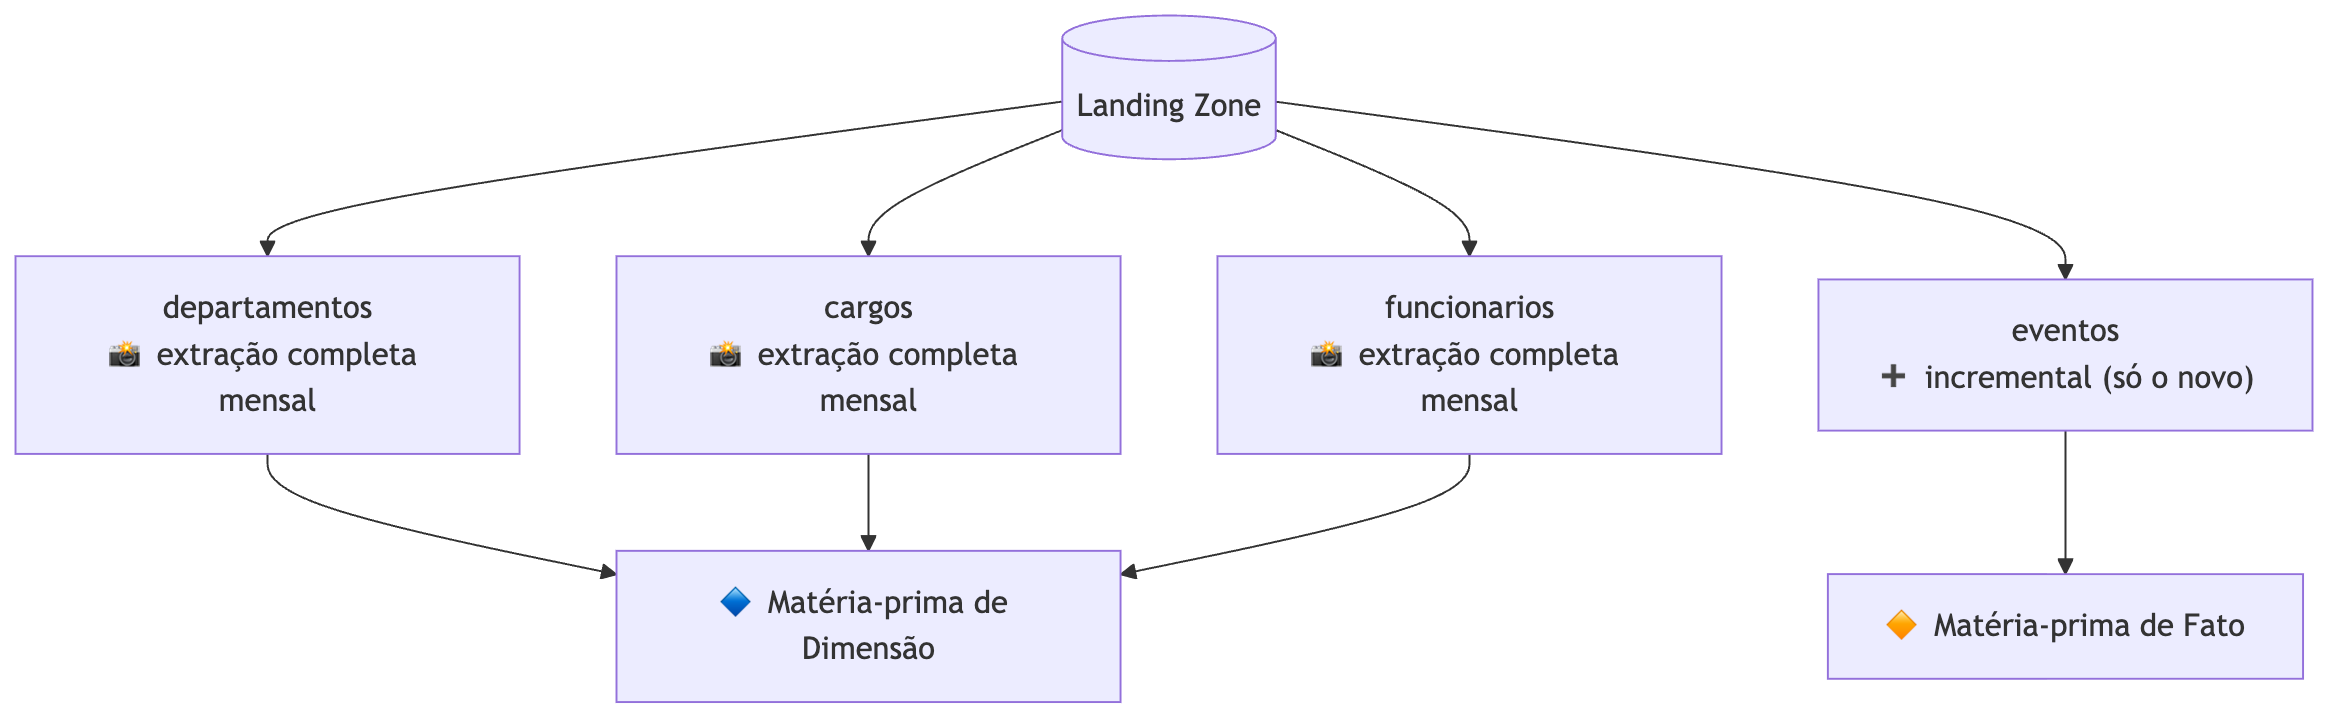

<details>
<summary>código-fonte do diagrama (mermaid)</summary>

```mermaid
flowchart TD
    LZ[("Landing Zone")]
    LZ --> DEP["departamentos<br/>📸 extração completa mensal"]
    LZ --> CAR["cargos<br/>📸 extração completa mensal"]
    LZ --> FUN["funcionarios<br/>📸 extração completa mensal"]
    LZ --> EVT["eventos<br/>➕ incremental (só o novo)"]

    DEP --> DIM["🔷 Matéria-prima de Dimensão"]
    CAR --> DIM
    FUN --> DIM
    EVT --> FATO["🔶 Matéria-prima de Fato"]
```

</details>

### Generalizando o Bronze

A função `etl_bronze_departamentos` que escrevemos lá atrás já faz exatamente o que precisamos para `cargos`, `funcionarios` e `eventos` — só o nome da entidade muda. Vamos generalizar essa função uma única vez, em vez de copiar e colar com pequenas variações para cada tabela nova.

In [ ]:
def etl_bronze_generico(nome_entidade, caminho_landing=None, caminho_bronze='../data/lakehouse/bronze'):
    caminho_landing = caminho_landing or f'../data/landing/{nome_entidade}'

    # lê todas as partições mensais, sem transformar nada
    caminhos_particoes = sorted(glob.glob(f'{caminho_landing}/dt=*/{nome_entidade}.csv'))

    partes = []
    for caminho in caminhos_particoes:
        df_particao = pd.read_csv(caminho)
        # metadados de auditoria: de onde veio e quando foi ingerido
        df_particao['_arquivo_origem'] = caminho
        df_particao['_timestamp_ingestao'] = datetime.now().isoformat(timespec='seconds')
        partes.append(df_particao)

    df_bronze = pd.concat(partes, ignore_index=True)

    os.makedirs(caminho_bronze, exist_ok=True)
    df_bronze.to_csv(f'{caminho_bronze}/{nome_entidade}.csv', index=False)

    print(f'[BRONZE] {len(df_bronze)} linhas de "{nome_entidade}" gravadas a partir de {len(caminhos_particoes)} partições.')
    return df_bronze

### Dimensão `cargo` (SCD Tipo 1)

`cargos` tem o mesmo formato de `departamentos`: uma extração completa por mês, onde a versão mais recente de cada cargo já é suficiente para a análise. Vamos generalizar também a lógica de `etl_silver_departamentos` — "mantenha só a linha mais recente de cada chave" — em uma função reutilizável para qualquer dimensão Tipo 1.

In [ ]:
def etl_silver_dimensao_tipo1(nome_entidade, coluna_chave, caminho_bronze='../data/lakehouse/bronze', caminho_silver='../data/lakehouse/silver'):
    df_bronze = pd.read_csv(f'{caminho_bronze}/{nome_entidade}.csv')
    df_bronze['data_extracao'] = pd.to_datetime(df_bronze['data_extracao'])

    # mantém apenas o registro mais recente de cada chave, descartando os metadados de auditoria do Bronze
    df_silver = (
        df_bronze
        .sort_values('data_extracao')
        .drop_duplicates(subset=coluna_chave, keep='last')
        .drop(columns=['_arquivo_origem', '_timestamp_ingestao'])
        .reset_index(drop=True)
    )

    os.makedirs(caminho_silver, exist_ok=True)
    df_silver.to_csv(f'{caminho_silver}/{nome_entidade}.csv', index=False)

    print(f'[SILVER] {len(df_silver)} "{nome_entidade}" únicos (SCD Tipo 1) após deduplicação.')
    return df_silver

### Dimensão `funcionario` (SCD Tipo 2): preservando o histórico completo

Lá atrás, na camada Silver de `departamentos`, deixamos um aviso: manter só a versão mais recente de cada registro é uma SCD Tipo 1, e um pipeline de produção normalmente precisaria do Tipo 2 para preservar histórico. Chegou a hora de implementar esse Tipo 2 de verdade — e `funcionarios` é o caso perfeito, porque `departamento_id` e `cargo_id` mudam ao longo do tempo (transferências e promoções) sem que o `funcionario_id` mude.

A lógica: comparamos cada extração mensal de um funcionário com a extração anterior; sempre que `departamento_id`, `cargo_id` ou `status` mudam, uma **nova versão** é aberta, com sua própria `data_inicio_vigencia`, `data_fim_vigencia` e uma chave substituta (`sk_funcionario`) — exatamente os campos de controle Tipo 2 que vimos na teoria.

In [ ]:
def etl_silver_dim_funcionario_scd2(caminho_bronze='../data/lakehouse/bronze', caminho_silver='../data/lakehouse/silver'):
    df = pd.read_csv(f'{caminho_bronze}/funcionarios.csv')
    df['data_extracao'] = pd.to_datetime(df['data_extracao'])
    df = df.sort_values(['funcionario_id', 'data_extracao'])

    # colunas rastreadas: qualquer mudança nelas abre uma nova versão do funcionário
    colunas_rastreadas = ['departamento_id', 'cargo_id', 'status']
    mudou = (
        df.groupby('funcionario_id')[colunas_rastreadas]
        .apply(lambda g: (g != g.shift()).any(axis=1))
        .reset_index(level=0, drop=True)
    )
    df['nova_versao'] = mudou.values

    # início de vigência = primeira extração em que aquela combinação de valores apareceu
    df['data_inicio_vigencia'] = df['data_extracao'].where(df['nova_versao'])
    df['data_inicio_vigencia'] = df.groupby('funcionario_id')['data_inicio_vigencia'].ffill()

    # mantém só as linhas que de fato abrem uma nova versão
    df_versoes = (
        df[df['nova_versao']]
        .drop(columns=['nova_versao', 'data_extracao'])
        .reset_index(drop=True)
    )

    # fim de vigência = início da próxima versão do mesmo funcionário menos um dia; nulo = versão ainda vigente
    df_versoes['data_fim_vigencia'] = (
        df_versoes.groupby('funcionario_id')['data_inicio_vigencia'].shift(-1) - pd.Timedelta(days=1)
    )
    df_versoes['is_current'] = df_versoes['data_fim_vigencia'].isna()

    # chave substituta (surrogate key) sequencial, uma por versão
    df_versoes.insert(0, 'sk_funcionario', df_versoes.index + 1)

    os.makedirs(caminho_silver, exist_ok=True)
    df_versoes.to_csv(f'{caminho_silver}/dim_funcionario.csv', index=False)

    print(f'[SILVER] dim_funcionario com {len(df_versoes)} versões (SCD Tipo 2) para {df_versoes["funcionario_id"].nunique()} funcionários.')
    return df_versoes

### Tabela Fato: Eventos de RH

`eventos` já chega em formato de fato de transação — uma linha por evento, sem necessidade de deduplicar nada (cada `evento_id` é único por natureza). A camada Silver aqui só tipa a data corretamente.

In [ ]:
def etl_silver_eventos(caminho_bronze='../data/lakehouse/bronze', caminho_silver='../data/lakehouse/silver'):
    df_bronze = pd.read_csv(f'{caminho_bronze}/eventos.csv')
    df_bronze['data_evento'] = pd.to_datetime(df_bronze['data_evento'])

    df_silver = (
        df_bronze
        .drop(columns=['_arquivo_origem', '_timestamp_ingestao'])
        .reset_index(drop=True)
    )

    os.makedirs(caminho_silver, exist_ok=True)
    df_silver.to_csv(f'{caminho_silver}/eventos.csv', index=False)

    print(f'[SILVER] {len(df_silver)} eventos (sem deduplicação — cada evento é único por natureza).')
    return df_silver

### Ligando o Fato à Dimensão: o Join Temporal

A parte mais delicada de montar a Gold é ligar cada evento à versão *correta* de `dim_funcionario` — a que estava vigente na data do evento, não necessariamente a mais recente. Isso é o que chamamos de **join temporal**: em vez de casar só pela chave (`funcionario_id`), também exigimos que `data_evento` caia dentro do intervalo `[data_inicio_vigencia, data_fim_vigencia]` daquela versão.

> ⚠️ **Atenção:** o histórico de `eventos` começa em 2022, mas nossas extrações mensais — e, portanto, o início de vigência da primeira versão de cada funcionário em `dim_funcionario` — só começam em setembro de 2025. Isso é uma limitação real de qualquer SCD Tipo 2: só é possível reconstruir o histórico a partir do momento em que a captura começou. Para não descartar eventos antigos, tratamos a primeira versão conhecida de cada funcionário como válida também para qualquer evento anterior a ela.

Diagrama: o join temporal em ação — o evento é ligado à versão de `dim_funcionario` cuja janela de vigência contém a `data_evento`, não à versão mais recente.

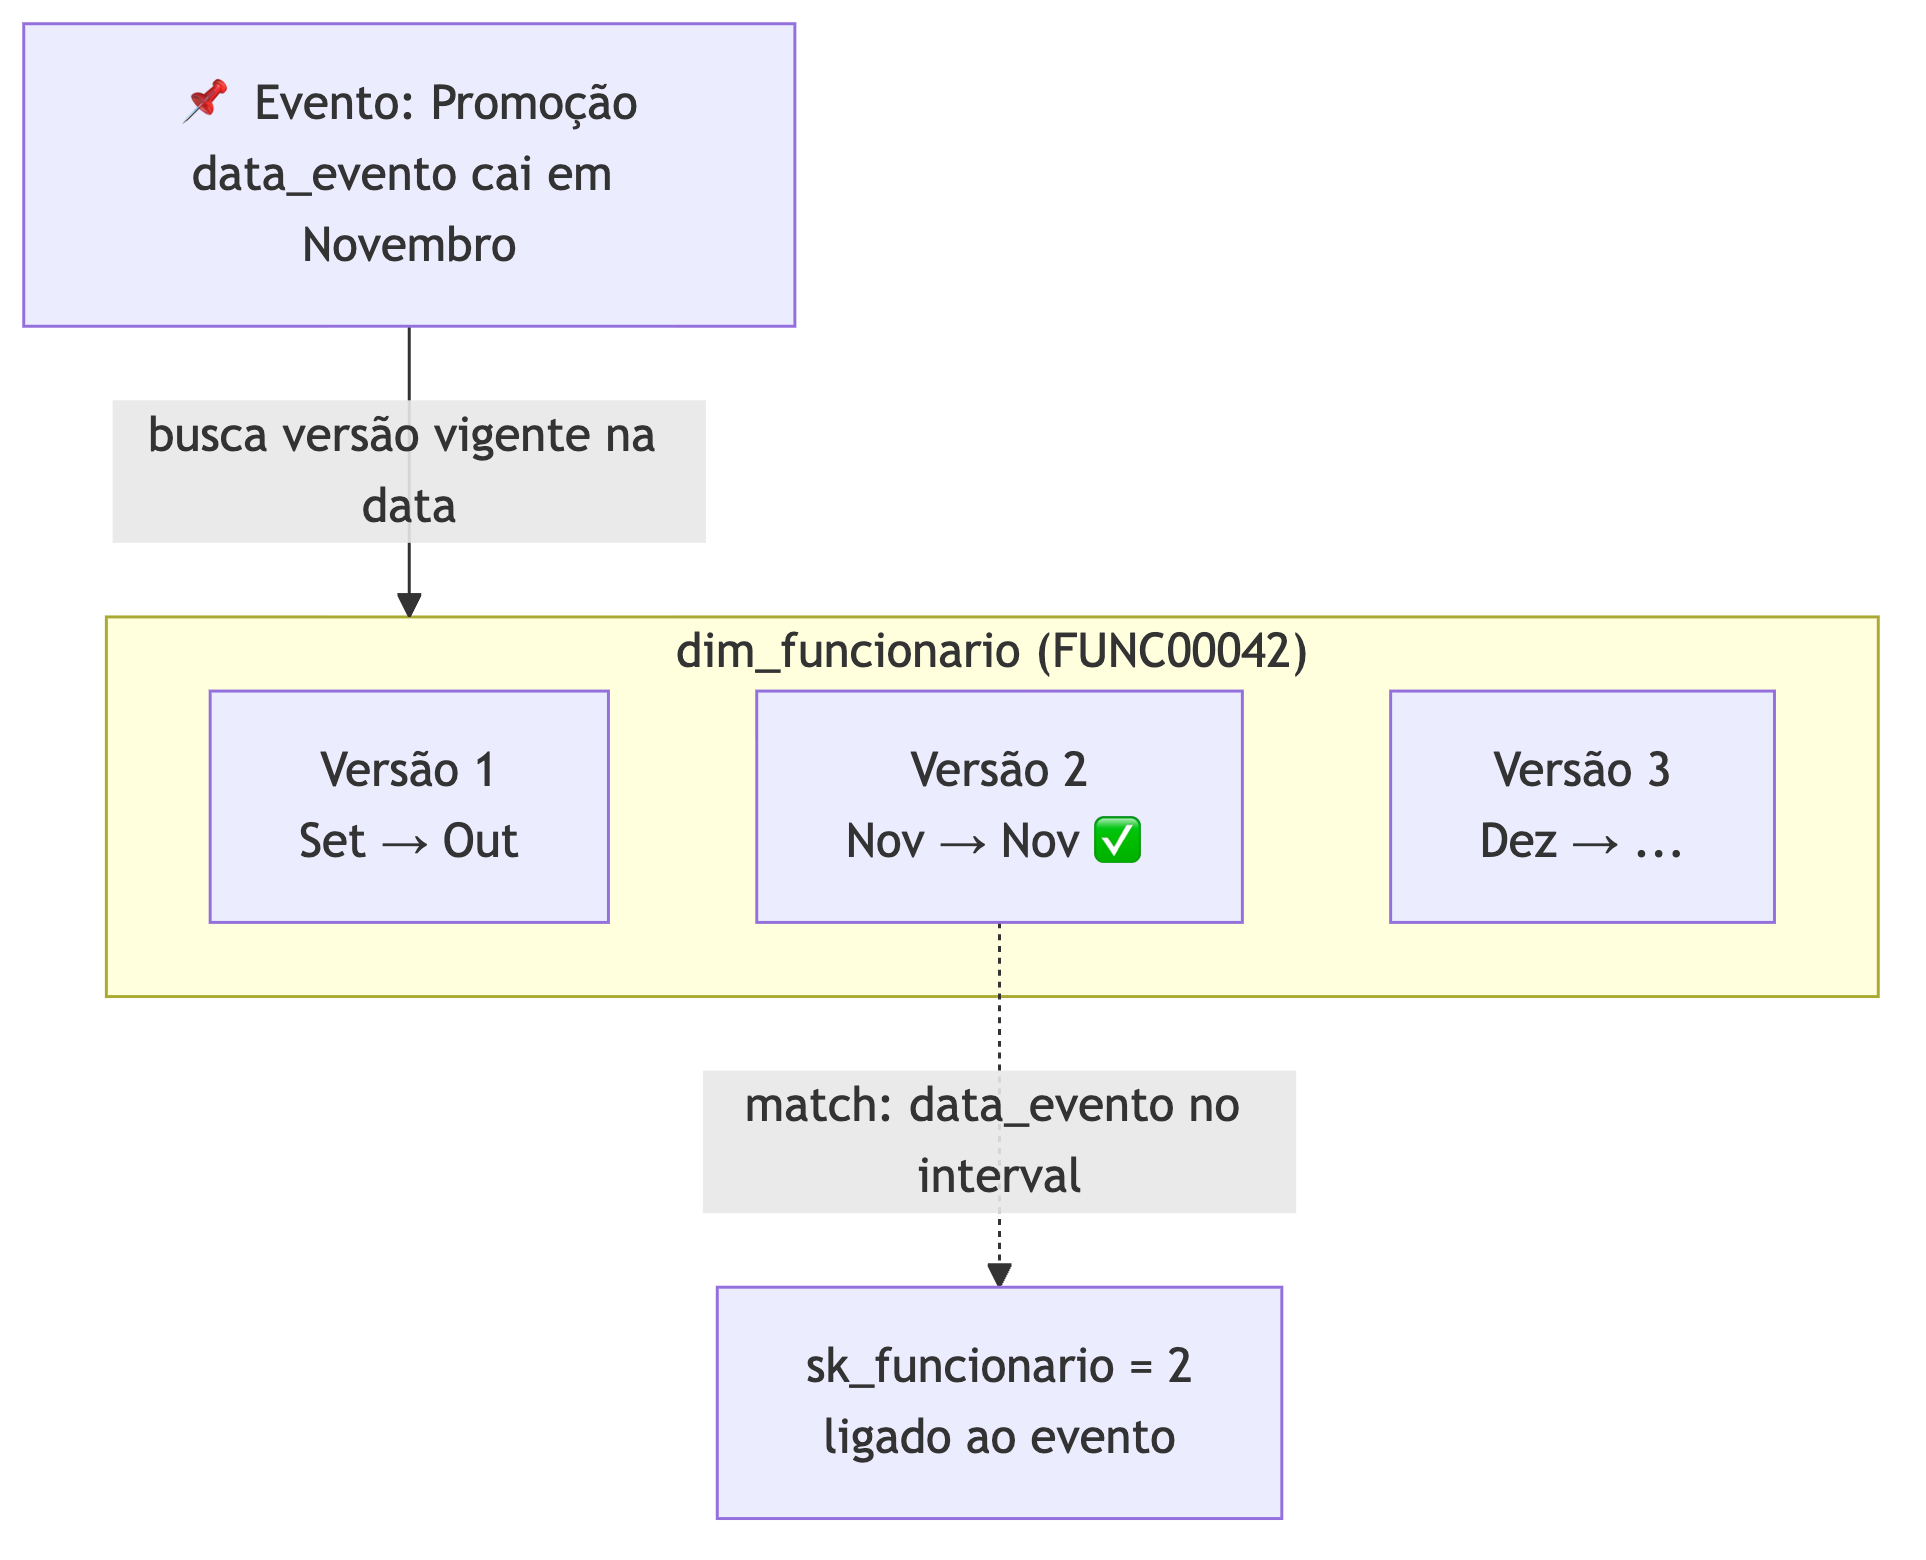

<details>
<summary>código-fonte do diagrama (mermaid)</summary>

```mermaid
flowchart TD
    E["📌 Evento: Promoção<br/>data_evento cai em Novembro"] -->|busca versão vigente na data| Dim

    subgraph Dim["dim_funcionario (FUNC00042)"]
        direction LR
        D1["Versão 1<br/>Set → Out"]
        D2["Versão 2<br/>Nov → Nov ✅"]
        D3["Versão 3<br/>Dez → ..."]
    end

    D2 -.match: data_evento no intervalo.-> R["sk_funcionario = 2<br/>ligado ao evento"]
```

</details>

In [ ]:
def etl_gold_fato_eventos_rh(caminho_silver='../data/lakehouse/silver', caminho_gold='../data/lakehouse/gold'):
    df_eventos = pd.read_csv(f'{caminho_silver}/eventos.csv', parse_dates=['data_evento'])
    dim_funcionario = pd.read_csv(
        f'{caminho_silver}/dim_funcionario.csv',
        parse_dates=['data_inicio_vigencia', 'data_fim_vigencia'],
    )

    # a primeira versão de cada funcionário também cobre eventos anteriores ao início da captura
    primeira_versao = dim_funcionario.groupby('funcionario_id')['data_inicio_vigencia'].transform('min')
    dim_funcionario['primeira_versao'] = dim_funcionario['data_inicio_vigencia'] == primeira_versao

    # join temporal: liga cada evento à versão do funcionário vigente na data do evento
    fato = df_eventos.merge(
        dim_funcionario[['sk_funcionario', 'funcionario_id', 'data_inicio_vigencia', 'data_fim_vigencia', 'primeira_versao']],
        on='funcionario_id',
        how='left',
    )
    vigente_na_data = (
        (fato['data_evento'] >= fato['data_inicio_vigencia'])
        | (fato['primeira_versao'] & (fato['data_evento'] < fato['data_inicio_vigencia']))
    ) & (
        fato['data_fim_vigencia'].isna() | (fato['data_evento'] <= fato['data_fim_vigencia'])
    )

    df_gold = (
        fato[vigente_na_data]
        [['evento_id', 'sk_funcionario', 'funcionario_id', 'data_evento', 'tipo_evento',
          'departamento_id', 'cargo_id', 'salario_anterior', 'salario_novo', 'motivo']]
        .sort_values('data_evento')
        .reset_index(drop=True)
    )

    os.makedirs(caminho_gold, exist_ok=True)
    df_gold.to_csv(f'{caminho_gold}/fato_eventos_rh.csv', index=False)

    print(f'[GOLD] tabela fato "fato_eventos_rh" gerada com {len(df_gold)} linhas (grão: 1 linha = 1 evento de RH).')
    return df_gold

### Orquestrando o Pipeline Dimensional

Assim como antes, respeitamos a ordem de dependência: Bronze de cada entidade primeiro, depois as dimensões (`dim_cargo` e `dim_funcionario`), depois o tratamento do fato, e só então a Gold — que precisa de `eventos` e `dim_funcionario` já prontos em Silver.

In [ ]:
etapas_dimensional = [
    ('bronze_cargos', lambda: etl_bronze_generico('cargos')),
    ('bronze_funcionarios', lambda: etl_bronze_generico('funcionarios')),
    ('bronze_eventos', lambda: etl_bronze_generico('eventos')),
    ('silver_dim_cargo', lambda: etl_silver_dimensao_tipo1('cargos', 'cargo_id')),
    ('silver_dim_funcionario', etl_silver_dim_funcionario_scd2),
    ('silver_eventos', etl_silver_eventos),
    ('gold_fato_eventos_rh', etl_gold_fato_eventos_rh),
]

print('Iniciando pipeline "modelo dimensional de RH"\n' + '-' * 40)
for nome_etapa, funcao_etapa in etapas_dimensional:
    inicio = time.time()
    funcao_etapa()
    duracao = time.time() - inicio
    print(f'  -> etapa "{nome_etapa}" concluída em {duracao:.2f}s')
print('-' * 40 + '\nPipeline concluído com sucesso.')

Vamos conferir se a `dim_funcionario` realmente preservou o histórico — algo que a versão Tipo 1 do início do notebook não conseguiria fazer. O `FUNC00042`, por exemplo, aparece em `eventos` como promovido em novembro de 2025.

In [ ]:
dim_funcionario = pd.read_csv('../data/lakehouse/silver/dim_funcionario.csv')
dim_funcionario[dim_funcionario['funcionario_id'] == 'FUNC00042'][
    ['sk_funcionario', 'funcionario_id', 'departamento_id', 'cargo_id', 'data_inicio_vigencia', 'data_fim_vigencia', 'is_current']
]

Repare nas quatro versões: o `cargo_id` muda de `C13` para `C12` bem no meio do histórico — exatamente quando o evento de Promoção acontece — e o `departamento_id` muda duas vezes depois disso, em transferências. Cada mudança virou uma linha nova, com sua própria janela de vigência, em vez de sobrescrever a anterior.

Diagrama: a mesma progressão de versões que vimos na tabela acima, agora como uma linha do tempo (datas ilustrativas — as suas podem variar conforme os dados carregados).

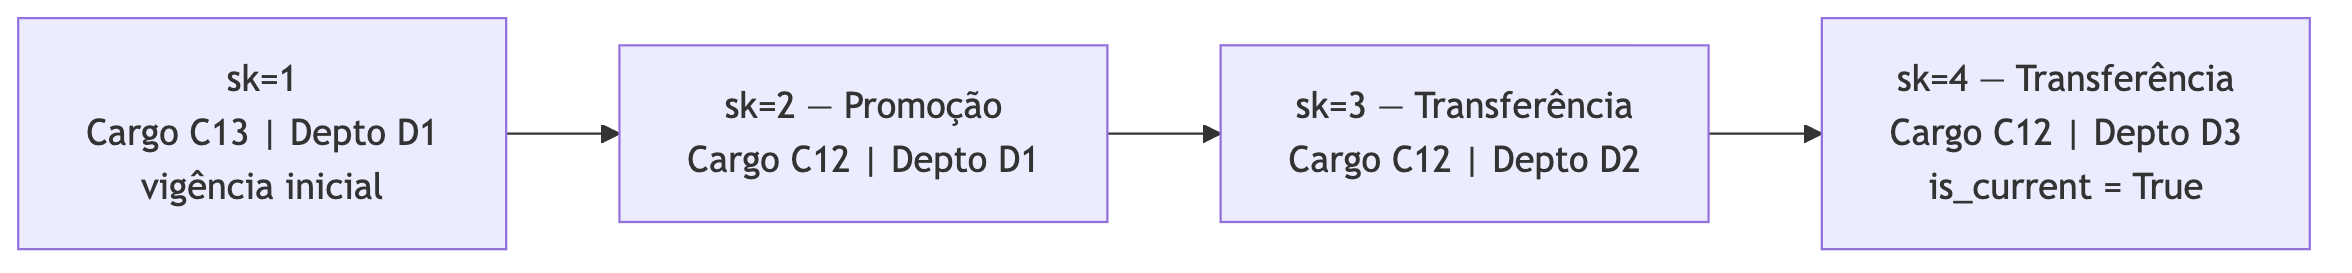

<details>
<summary>código-fonte do diagrama (mermaid)</summary>

```mermaid
flowchart LR
    V1["sk=1<br/>Cargo C13 | Depto D1<br/>vigência inicial"] --> V2["sk=2 — Promoção<br/>Cargo C12 | Depto D1"]
    V2 --> V3["sk=3 — Transferência<br/>Cargo C12 | Depto D2"]
    V3 --> V4["sk=4 — Transferência<br/>Cargo C12 | Depto D3<br/>is_current = True"]
```

</details>

### Consultando o Esquema Estrela

Diagrama: o esquema estrela que acabamos de construir, com a fato de eventos de RH cercada pelas três dimensões.

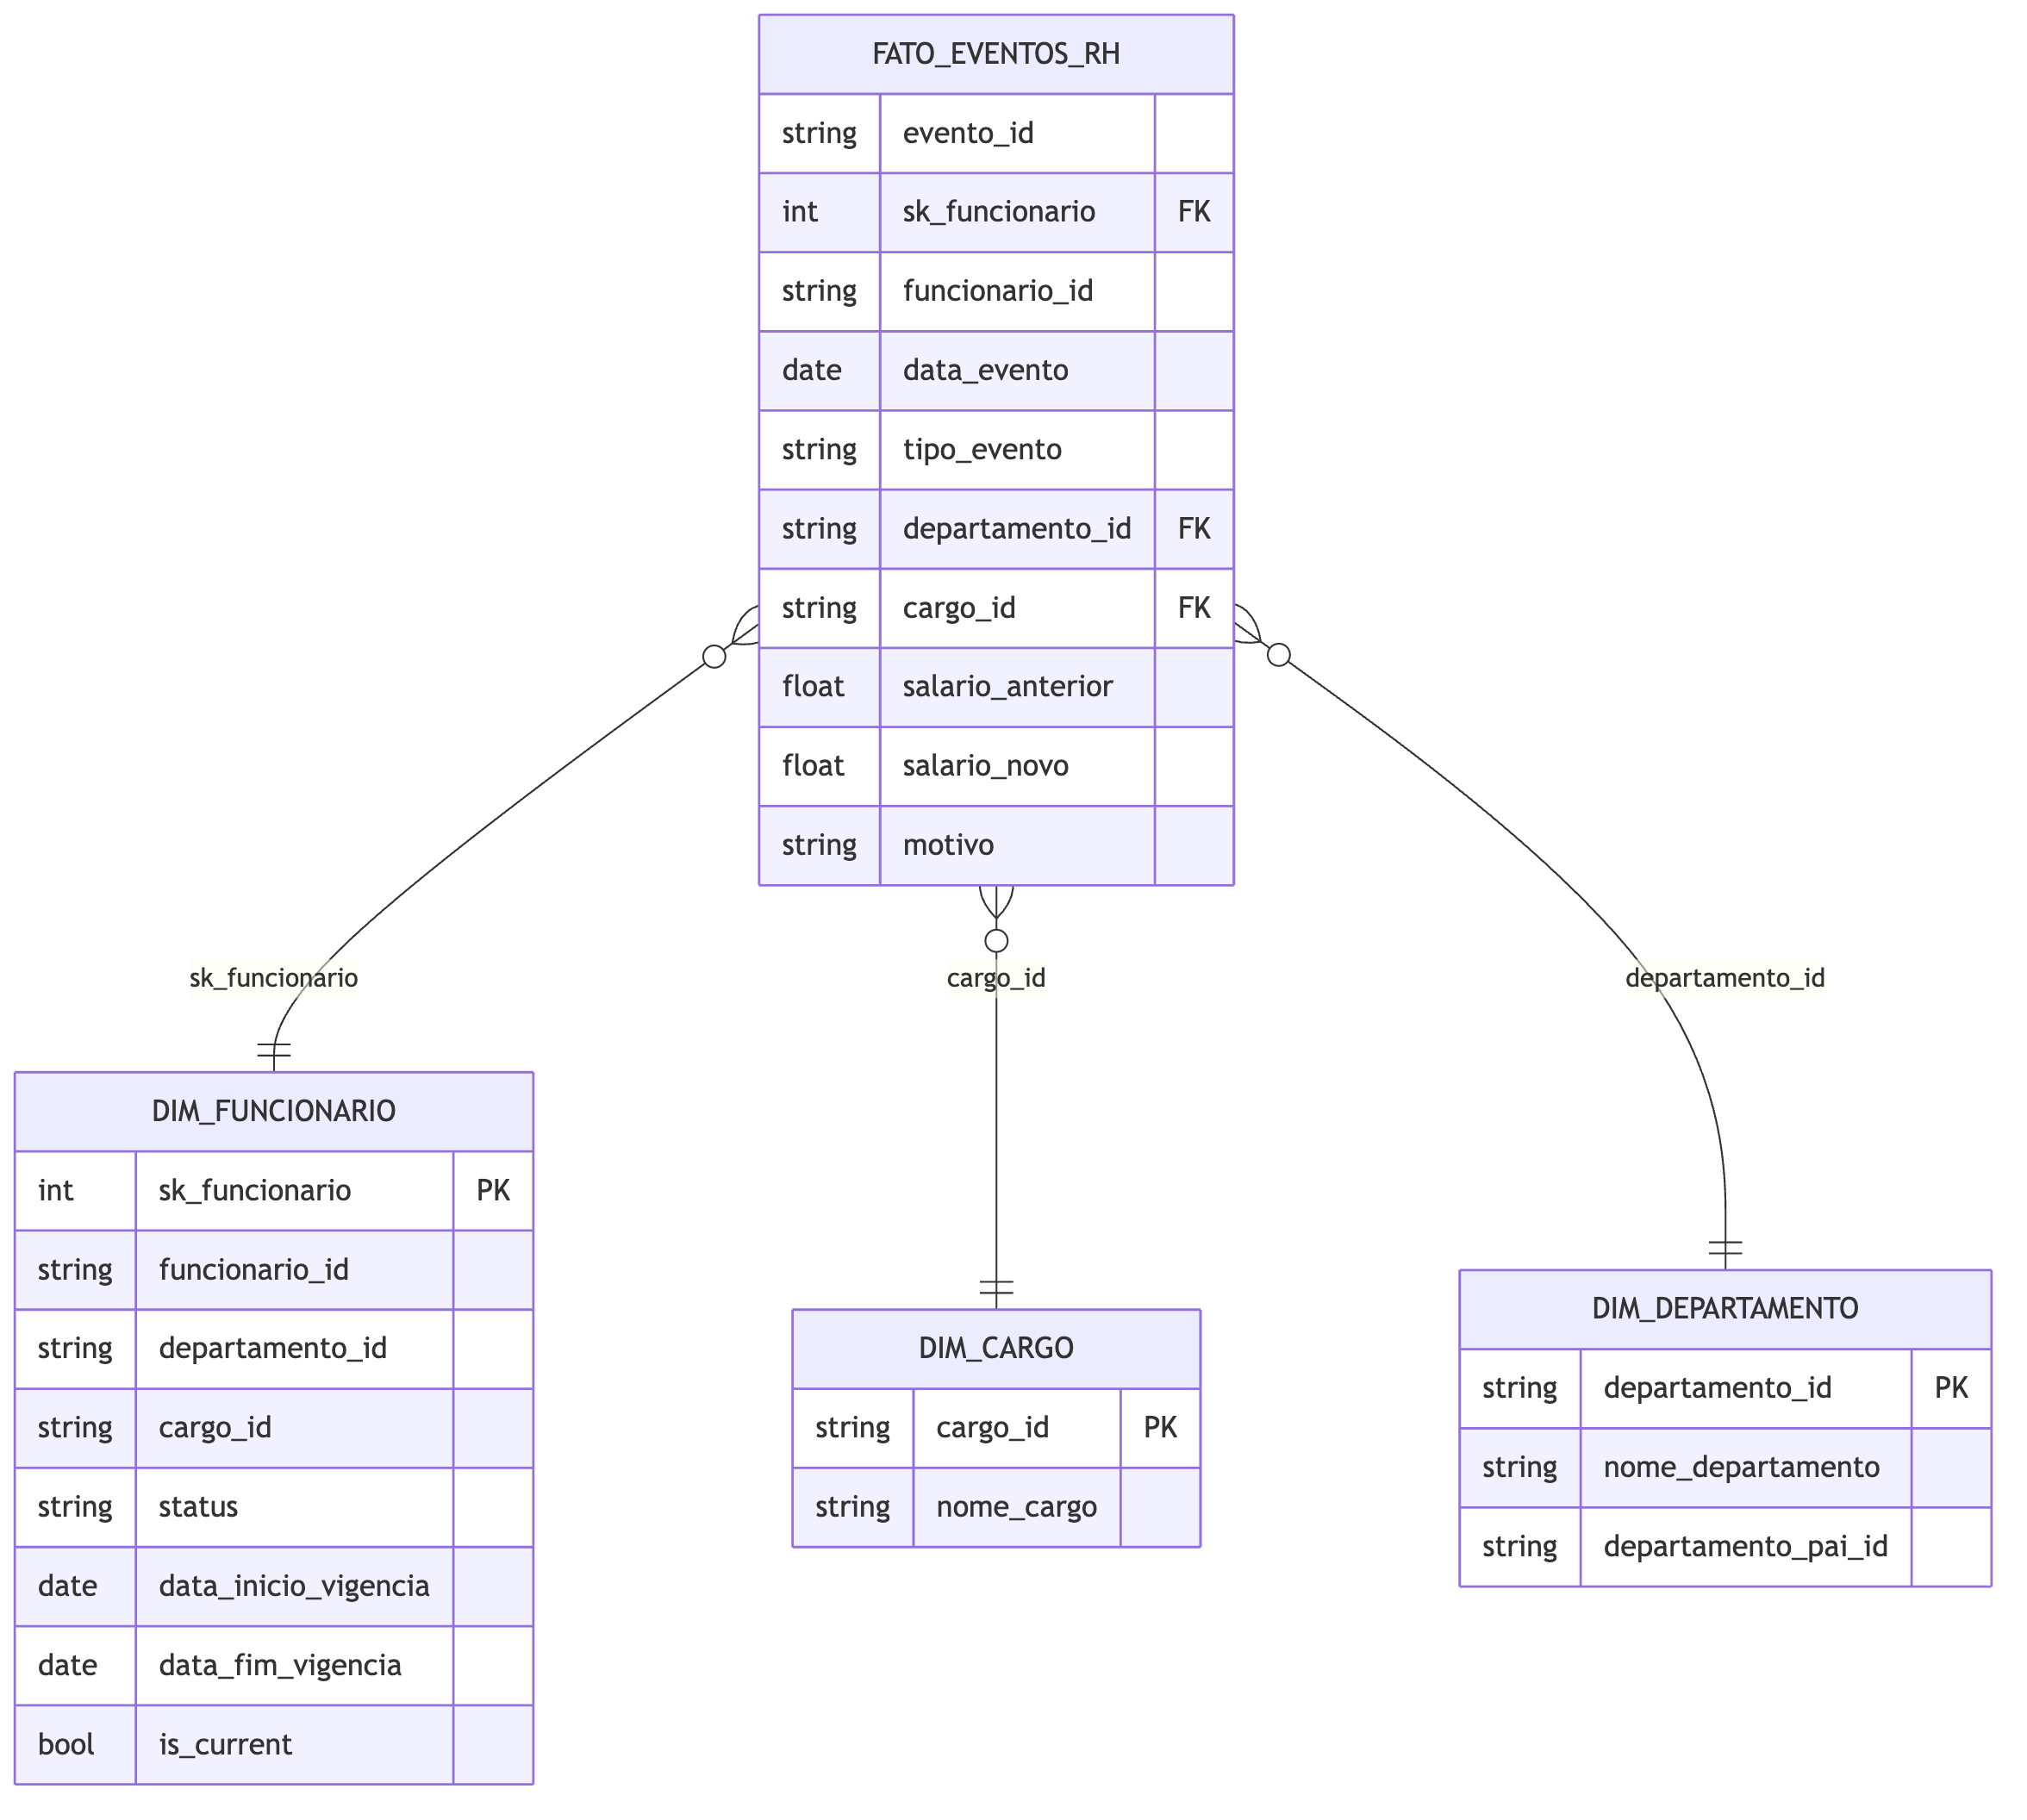

<details>
<summary>código-fonte do diagrama (mermaid)</summary>

```mermaid
erDiagram
    FATO_EVENTOS_RH }o--|| DIM_FUNCIONARIO : sk_funcionario
    FATO_EVENTOS_RH }o--|| DIM_CARGO : cargo_id
    FATO_EVENTOS_RH }o--|| DIM_DEPARTAMENTO : departamento_id

    FATO_EVENTOS_RH {
        string evento_id
        int sk_funcionario FK
        string funcionario_id
        date data_evento
        string tipo_evento
        string departamento_id FK
        string cargo_id FK
        float salario_anterior
        float salario_novo
        string motivo
    }
    DIM_FUNCIONARIO {
        int sk_funcionario PK
        string funcionario_id
        string departamento_id
        string cargo_id
        string status
        date data_inicio_vigencia
        date data_fim_vigencia
        bool is_current
    }
    DIM_CARGO {
        string cargo_id PK
        string nome_cargo
    }
    DIM_DEPARTAMENTO {
        string departamento_id PK
        string nome_departamento
        string departamento_pai_id
    }
```

</details>

Com a fato e as dimensões prontas, perguntas de negócio viram um `merge` seguido de um `groupby` direto — sem nenhuma lógica de deduplicação ou de "qual é o valor mais recente" espalhada pela consulta, porque isso já foi resolvido lá atrás, na modelagem.

In [ ]:
fato_eventos_rh = pd.read_csv('../data/lakehouse/gold/fato_eventos_rh.csv', parse_dates=['data_evento'])
dim_departamento = pd.read_csv('../data/lakehouse/silver/departamentos.csv')

# número de promoções por departamento, cruzando a fato com a dimensão de departamento
promocoes_por_departamento = (
    fato_eventos_rh[fato_eventos_rh['tipo_evento'] == 'Promoção']
    .merge(dim_departamento[['departamento_id', 'nome_departamento']], on='departamento_id', how='left')
    .groupby('nome_departamento')
    .size()
    .reset_index(name='qtd_promocoes')
    .sort_values('qtd_promocoes', ascending=False)
)
promocoes_por_departamento

Financeiro concentra o maior número de promoções do período — o tipo de pergunta que, sem um modelo dimensional por trás, exigiria reconstruir manualmente a versão de cada funcionário válida em cada data. Com fato e dimensões bem definidos, essa mesma pergunta (e qualquer variação dela — por cargo, por período, por tipo de evento) é só mais um `groupby`.

## Passo a Passo: Levando o Mesmo Padrão para a Nuvem

O mini Lakehouse local que acabamos de construir tem exatamente as mesmas três peças que qualquer Lakehouse "de verdade": uma camada de ingestão crua, uma de limpeza e uma de consumo analítico, executadas em uma ordem de dependência fixa. A diferença é que, na nuvem, cada uma dessas peças é implementada por um produto gerenciado específico. Veja como o mesmo pipeline (Bronze → Silver → Gold, com 3 notebooks/scripts orquestrados) é montado no **Microsoft Fabric** e no **Databricks**.

### No Microsoft Fabric

**1. Criar o workspace e os itens Lakehouse**

Crie um [workspace do Fabric](https://learn.microsoft.com/en-us/fabric/fundamentals/create-workspaces) e, dentro dele, um item **Lakehouse** para cada camada: `lh_bronze`, `lh_silver` e `lh_gold`. Isso é feito em **Novo item → pesquisar "Lakehouse" → nomear → Criar**. A documentação oficial de arquitetura medalhão do Fabric recomenda exatamente esse padrão — um Lakehouse por camada, cada um com suas próprias áreas **Files** (arquivos brutos) e **Tables** (tabelas Delta), ambas apoiadas no OneLake.

> 💡 **Dica:** para uma demonstração rápida, um único Lakehouse com pastas separadas também funciona — mas separar por Lakehouse (ou até por workspace) facilita aplicar permissões diferentes por camada mais adiante.

**2. Ingerir os arquivos brutos no Bronze**

Em `lh_bronze`: **Obter dados → Carregar arquivos** (`Get data → Upload files`) para subir o CSV (`departamentos.csv`) na área **Files** — a "zona de pouso" para dados crus, em qualquer formato. Em seguida, clique com o botão direito no arquivo → **Carregar para Tabelas → Nova tabela** (`Load to Tables → New table`): o Fabric infere o schema e grava automaticamente uma **tabela Delta** na área **Tables**. Para volumes maiores, o Fabric também oferece **atalhos (shortcuts)** — ponteiros de acesso direto a dados no ADLS Gen2, S3 ou em outro Lakehouse, sem copiar nada — indicados justamente para a camada Bronze.

**3. Notebook Silver e notebook Gold**

Crie um notebook Fabric (PySpark) que lê a tabela Delta de `lh_bronze`, limpa e deduplica os dados, e grava o resultado como tabela em `lh_silver` — a mesma lógica da função `etl_silver_departamentos` que escrevemos acima, agora em Spark. Crie um segundo notebook que lê `lh_silver`, agrega e grava em `lh_gold`. Para acessar um Lakehouse diferente do notebook a partir de outro, use o utilitário `notebookutils` (nome atual; `mssparkutils` é o alias legado, ainda funcional) — inclusive `notebookutils.notebook.run()`/`runMultiple()` permitem chamar um notebook a partir de outro programaticamente.

Os notebooks completos, já cobrindo o esquema estrela inteiro (dimensões Tipo 1 e Tipo 2, e as duas tabelas Gold), estão em `scripts/fabric/silver.ipynb` e `scripts/fabric/gold.ipynb` neste repositório — prontos para importar no workspace, bastando ajustar os nomes dos Lakehouses conforme o passo 1.

> 💡 **Dica:** se PySpark ainda é novidade, o tutorial oficial [Lakehouse tutorial: Prepare and transform data (Microsoft Fabric)](https://learn.microsoft.com/en-us/fabric/data-engineering/tutorial-lakehouse-data-preparation) ensina os principais comandos na prática, direto em um notebook Fabric.

**4. Orquestrar com um Data pipeline**

Crie um item **Data pipeline** (**Novo item → Data pipeline**, dentro do workload Data Factory). Adicione três **atividades do tipo Notebook** (`Notebook activity`), uma para cada etapa, e conecte-as em sequência pelas setas de dependência de sucesso (Bronze → Silver → Gold) — assim como fizemos com a lista `etapas` no exemplo local, mas agora com retentativas, alertas e paralelismo geridos pela própria plataforma. Configure um **gatilho de agendamento** (`Schedule`) para rodar, por exemplo, todo dia às 6h — ou um gatilho por evento, disparado quando um novo arquivo chega no armazenamento.

> 📝 **Nota:** o Fabric também oferece **materialized lake views**, uma forma declarativa de descrever as transformações Bronze/Silver/Gold em SQL, deixando que a própria plataforma calcule a ordem de execução e a estratégia de atualização — o equivalente, no Fabric, ao Lakeflow Declarative Pipelines do Databricks (próxima seção).

### No Databricks

**1. Organizar o Unity Catalog**

Dentro de um catálogo do **Unity Catalog**, crie três *schemas* (o equivalente a "bancos" dentro do catálogo): `bronze`, `silver` e `gold` — por exemplo, `meu_catalogo.bronze`, `meu_catalogo.silver`, `meu_catalogo.gold`. É exatamente esse padrão de nomenclatura que a documentação oficial usa em seus próprios exemplos de arquitetura medalhão.

**2. Ingerir os arquivos brutos em um Volume**

Dentro do schema `bronze`, crie um **Volume** (armazenamento de arquivos governado pelo Unity Catalog): no Catalog Explorer, **Create volume**, depois **Upload to this volume** para subir o CSV. Um notebook Bronze lê os arquivos desse volume e grava como **tabela Delta gerenciada** em `meu_catalogo.bronze.departamentos` — no Databricks, toda tabela criada sem especificar formato já nasce como tabela Delta.

**3. Notebook Silver e notebook Gold**

Um segundo notebook lê `meu_catalogo.bronze.departamentos`, aplica a mesma lógica de limpeza e deduplicação da função `etl_silver_departamentos`, e grava em `meu_catalogo.silver.departamentos`. Um terceiro notebook lê o Silver, agrega, e grava em `meu_catalogo.gold.estrutura_organizacional`. Para prototipar rapidamente, um notebook pode chamar outro com `%run ./caminho_do_notebook` (herda variáveis e funções) ou `dbutils.notebook.run(caminho, timeout, parametros)` (executa como um job à parte, com parâmetros) — mas, para produção, a própria documentação recomenda migrar esse encadeamento para a ferramenta de orquestração nativa.

Os notebooks completos, já cobrindo o esquema estrela inteiro (dimensões Tipo 1 e Tipo 2, e as duas tabelas Gold), estão em `scripts/databricks/silver.ipynb` e `scripts/databricks/gold.ipynb` neste repositório — basta importá-los no workspace e preencher o widget `catalogo` com o nome do seu catálogo.

> 💡 **Dica:** se PySpark ainda é novidade, o guia oficial [PySpark on Databricks](https://docs.databricks.com/aws/en/pyspark/) cobre os principais comandos — DataFrames, seleção, filtro, `join`, agregação — com exemplos prontos para colar em um notebook Databricks.

**4. Orquestrar com Lakeflow Jobs**

No menu lateral **Jobs & Pipelines** (o nome do produto na documentação é **Lakeflow Jobs** — o sucessor direto do que era chamado de "Databricks Workflows"), crie um **Job** com três *tasks* do tipo Notebook, uma para cada etapa. Em cada task, defina **"Depends on"** apontando para a task anterior, formando a mesma cadeia Bronze → Silver → Gold. Configure um **trigger** de agendamento (cron) ou baseado em evento (chegada de um novo arquivo no armazenamento em nuvem).

> 📝 **Nota:** como alternativa mais declarativa, o Databricks oferece o **Lakeflow Declarative Pipelines** (o nome atual do que já foi chamado de Delta Live Tables / DLT): em vez de escrever três notebooks e orquestrá-los manualmente, você declara cada tabela (`@dp.table`) e a própria plataforma resolve o grafo de dependências e a atualização incremental. Para quem está começando, o **Lakeflow Designer** oferece ainda uma versão sem código para montar esse mesmo tipo de pipeline visualmente.

> 💡 **Dica:** a **Databricks Community Edition** foi descontinuada em janeiro de 2026 e substituída pela **Databricks Free Edition** — é por ela que vale a pena começar se você quiser reproduzir este passo a passo sem custo.

## Saiba Mais

**Arquitetura medalhão (documentação oficial):**
- [Medallion architecture (Databricks)](https://docs.databricks.com/aws/en/lakehouse/medallion)
- [Medallion Lakehouse Architecture (Microsoft Fabric)](https://learn.microsoft.com/en-us/fabric/onelake/onelake-medallion-lakehouse-architecture)
- [Tutorial: Lakehouse end-to-end (Microsoft Fabric)](https://learn.microsoft.com/en-us/fabric/data-engineering/tutorial-lakehouse-introduction)

**Databricks:**
- [Jobs & Pipelines / Lakeflow Jobs](https://docs.databricks.com/aws/en/jobs/)
- [Unity Catalog](https://docs.databricks.com/aws/en/data-governance/unity-catalog/)
- [Delta Lake quickstart](https://docs.databricks.com/aws/en/delta/tutorial)
- [Lakeflow Declarative Pipelines (Delta Live Tables)](https://docs.databricks.com/aws/en/ldp/concepts/where-is-dlt)
- [Databricks Free Edition](https://docs.databricks.com/aws/en/getting-started/free-edition)
- [PySpark on Databricks](https://docs.databricks.com/aws/en/pyspark/)

**Microsoft Fabric:**
- [Notebook activity (Data Factory)](https://learn.microsoft.com/en-us/fabric/data-factory/notebook-activity)
- [Notebook utilities (notebookutils)](https://learn.microsoft.com/en-us/fabric/data-engineering/notebook-utilities)
- [Quickstart: criar um Lakehouse](https://learn.microsoft.com/en-us/fabric/onelake/quickstart-get-data)
- [Lakehouse tutorial: Prepare and transform data (PySpark)](https://learn.microsoft.com/en-us/fabric/data-engineering/tutorial-lakehouse-data-preparation)

**Outras plataformas:**
- [Introducing Polaris Catalog (Snowflake)](https://www.snowflake.com/en/blog/introducing-polaris-catalog/)
- [Amazon S3 Tables / Lake Formation (AWS)](https://docs.aws.amazon.com/lake-formation/latest/dg/create-s3-tables-catalog.html)
- [Lakehouse for Apache Iceberg (Google Cloud)](https://docs.cloud.google.com/lakehouse/docs/introduction)
- [IOMETE (site oficial)](https://iomete.com)
- [Planos e modelo de cobrança do IOMETE](https://iomete.com/pricing)
- [Disparando jobs Spark via Airflow no IOMETE](https://iomete.com/resources/user-guide/spark-jobs/airflow)

## Finalizando

Nesta demonstração você saiu de um comparativo objetivo das principais plataformas de Big Data do mercado, passou por um mini Lakehouse rodando localmente com pandas para fixar a mecânica de Bronze, Silver e Gold, evoluiu esse mesmo pipeline para um esquema estrela completo — com uma dimensão SCD Tipo 2 e um join temporal ligando fato e dimensão — e chegou a um passo a passo real de como esse mesmo padrão é implementado no Microsoft Fabric e no Databricks, incluindo a orquestração do pipeline.

A peça mais importante para levar daqui: a arquitetura medalhão não é exclusiva de nenhuma ferramenta. É um padrão de organização de dados que qualquer plataforma de Lakehouse — gerenciada ou não — pode implementar, com nomes de produtos diferentes cumprindo exatamente os mesmos papéis.

Um abraço e até a próxima,

Walter.